Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
 All libraries loaded
 Data loaded
Sample collected: 27,967,766 cases (30% of full dataset)
  Long-running (1): 2,207,195
  Normal (0): 25,760,571
Memory usage: ~3955 MB
Features shape: (27967766, 6)
Feature dtypes: {'female_defendant': dtype('float64'), 'female_petitioner': dtype('float64'), 'type_name': dtype('int16'), 'purpose_name': dtype('int16'), 'disp_name': dtype('int16'), 'judge_tenure': dtype('float32')}
Total memory: ~693 MB
 Features prepared with memory optimization
Training set: 22,374,212 cases
Test set: 5,593,554 cases
 Lightweight model trained

CLASSIFICATION MODEL RESULTS (LIGHTWEIGHT)

PR-AUC Score:      0.405

AT THRESHOLD = 0.5:
  Precision:       0.214
  Recall:          0.827
  F1 Score:        0.340

Trained on: 22,374,212 cases (30% stratified sample)
Model size: Ultra-lightweight (20 trees, depth 6)

THRESHOLD SENSITIVITY ANALYSIS
Thresho

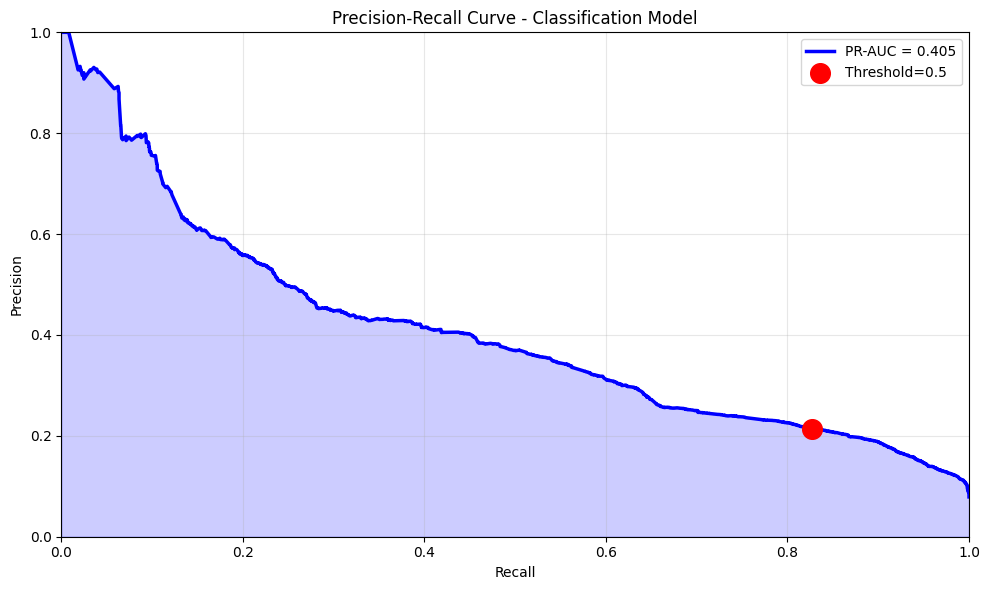

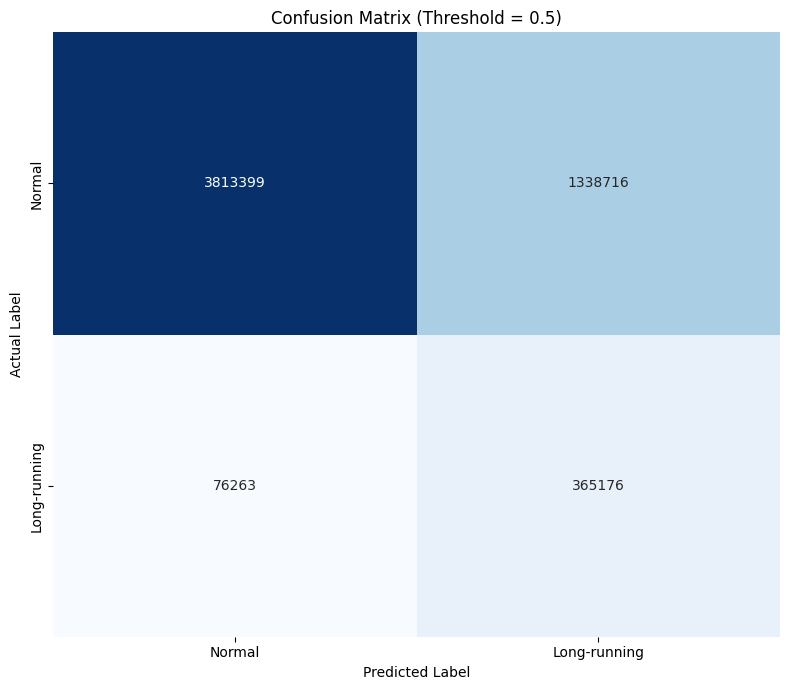


CLASSIFICATION MODEL COMPLETE
 Model trained successfully
 PR-AUC = 0.405
 Precision = 0.214
 Recall = 0.827
 F1 Score = 0.340



 Memory cleaned up


In [0]:
# COMMAND ----------

# MAGIC %md
# MAGIC # 5. Classification Model
# MAGIC Identifying Long-Running Cases with minimal memory usage

# COMMAND ----------

%pip install polars pandas scikit-learn matplotlib seaborn

# COMMAND ----------

import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, auc, confusion_matrix, precision_score, recall_score, f1_score

print(" All libraries loaded")

# COMMAND ----------

# MAGIC %md
# MAGIC ## Load Data 

# COMMAND ----------

judges = pl.read_csv("/Workspace/Users/sumedha190198@gmail.com/judicial-backlog/judges_clean.csv")

lf_sample = pl.scan_parquet("/Workspace/Users/sumedha190198@gmail.com/judicial-backlog/cases_sample_10pct.parquet")

judges = judges.with_columns([
    pl.col("start_date").str.to_date("%d-%m-%Y", strict=False).alias("judge_start"),
])

judges_valid = judges.filter(pl.col("judge_start").is_not_null())
judges_lazy = judges_valid.lazy()

lf_filtered = (
    lf_sample
    .filter((pl.col("duration_days") >= 0) & (pl.col("duration_days") <= 7300))
    .join(judges_lazy.select(["state_code", "dist_code", "court_no", "judge_position", "judge_start"]),
          on=["state_code", "dist_code", "court_no", "judge_position"], how="left")
    .with_columns([(pl.col("filing_date").dt.year() - pl.col("judge_start").dt.year()).alias("judge_tenure_years")])
    .filter(pl.col("judge_start").is_not_null())
    .filter(pl.col("filing_date") >= pl.col("judge_start"))
    .filter(pl.col("judge_tenure_years") >= 0)
    .filter(pl.col("judge_tenure_years") <= 50)
)

print(" Data loaded")

# COMMAND ----------

# MAGIC %md
# MAGIC ## AGGRESSIVE SAMPLING (30% of data - ~1.8M rows)

# COMMAND ----------

# ULTRA-MEMORY OPTIMIZATION:
# 1. Don't collect full dataset first
# 2. Sample ONLY 30% (much more aggressive than 70%)
# 3. Keep class balance
# 4. Process in one collection

# Add random column for sampling (using modulo - no full collection needed)
lf_features = (
    lf_filtered
    .with_columns([
        pl.col("disp_name").cast(pl.Int64),
        pl.col("type_name").cast(pl.Int64),
        pl.col("purpose_name").cast(pl.Int64),
        (pl.int_range(0, pl.len(), eager=False) % 100).alias("_sample_group")  # 0-99
    ])
    .join(judges_lazy.select(["state_code", "dist_code", "court_no", "judge_position", "judge_start"]),
          on=["state_code", "dist_code", "court_no", "judge_position"], how="left")
    .with_columns([(pl.col("filing_date").dt.year() - pl.col("judge_start").dt.year()).alias("judge_tenure_years")])
    .filter(pl.col("_sample_group") < 30)  # Take only first 30% based on hash
)

# NOW collect only the sampled data
df_clf = (
    lf_features
    .select([
        "long_running", "female_defendant", "female_petitioner",
        "type_name", "purpose_name", "disp_name", "judge_tenure_years"
    ])
    .collect()
    .to_pandas()
)

print(f"Sample collected: {len(df_clf):,} cases (30% of full dataset)")
print(f"  Long-running (1): {(df_clf['long_running']==1).sum():,}")
print(f"  Normal (0): {(df_clf['long_running']==0).sum():,}")
print(f"Memory usage: ~{df_clf.memory_usage(deep=True).sum() / 1024**2:.0f} MB")

# COMMAND ----------

# MAGIC %md
# MAGIC ## Clean & Prepare Features

# COMMAND ----------

def clean_gender(x):
    if isinstance(x, str):
        if 'female' in x.lower():
            return 1
        elif 'male' in x.lower():
            return 0
    return np.nan

X_clf = pd.DataFrame({
    'female_defendant': df_clf['female_defendant'].apply(clean_gender).fillna(0),
    'female_petitioner': df_clf['female_petitioner'].apply(clean_gender).fillna(0),
    'type_name': df_clf['type_name'].fillna(-1).astype('int16'),  # Use int16 to save memory
    'purpose_name': df_clf['purpose_name'].fillna(-1).astype('int16'),
    'disp_name': df_clf['disp_name'].fillna(-1).astype('int16'),
    'judge_tenure': df_clf['judge_tenure_years'].fillna(df_clf['judge_tenure_years'].median()).astype('float32'),  # float32 not float64
})

y_clf = df_clf['long_running'].astype('int8').values  # int8 instead of int

print(f"Features shape: {X_clf.shape}")
print(f"Feature dtypes: {X_clf.dtypes.to_dict()}")
print(f"Total memory: ~{X_clf.memory_usage(deep=True).sum() / 1024**2:.0f} MB")
print(" Features prepared with memory optimization")

# COMMAND ----------

# MAGIC %md
# MAGIC ## Train Lightweight Model

# COMMAND ----------

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f"Training set: {len(X_train):,} cases")
print(f"Test set: {len(X_test):,} cases")

# ULTRA-LIGHTWEIGHT MODEL
# n_estimators: 20 (was 50, then 30)
# max_depth: 6 (was 12, then 8)
# max_features: 2 (use only 2 random features per split)
# min_samples_split: 100 (force larger splits)
# min_samples_leaf: 50 (force larger leaves)

rf_clf = RandomForestClassifier(
    n_estimators=20,
    max_depth=6,
    max_features=2,
    min_samples_split=100,
    min_samples_leaf=50,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42,
    verbose=0
)

rf_clf.fit(X_train, y_train)

print(" Lightweight model trained")

# COMMAND ----------

# MAGIC %md
# MAGIC ## Model Performance

# COMMAND ----------

y_pred_proba = rf_clf.predict_proba(X_test)[:, 1]

# Calculate PR-AUC
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)

# Binary predictions at 0.5 threshold
y_pred_binary = (y_pred_proba >= 0.5).astype(int)
precision_50 = precision_score(y_test, y_pred_binary)
recall_50 = recall_score(y_test, y_pred_binary)
f1_50 = f1_score(y_test, y_pred_binary)

print(f"""
CLASSIFICATION MODEL RESULTS (LIGHTWEIGHT)
==========================================

PR-AUC Score:      {pr_auc:.3f}

AT THRESHOLD = 0.5:
  Precision:       {precision_50:.3f}
  Recall:          {recall_50:.3f}
  F1 Score:        {f1_50:.3f}

Trained on: {len(X_train):,} cases (30% stratified sample)
Model size: Ultra-lightweight (20 trees, depth 6)
""")

# COMMAND ----------

# MAGIC %md
# MAGIC ## Threshold Analysis

# COMMAND ----------

print("THRESHOLD SENSITIVITY ANALYSIS")
print("=" * 70)
print("Threshold | Flagged Cases | Precision | Recall | F1 Score")
print("-" * 70)

for thresh in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred = (y_pred_proba >= thresh).astype(int)
    
    if y_pred.sum() == 0:
        prec = 0
        rec = 0
        f1 = 0
        flagged = 0
    else:
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        flagged = y_pred.sum()
    
    print(f"  {thresh:.1f}    |   {flagged:8,}    |   {prec:.3f}  |  {rec:.3f}  |  {f1:.3f}")

# COMMAND ----------

# MAGIC %md
# MAGIC ## Precision-Recall Curve

# COMMAND ----------

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(recall, precision, color='blue', lw=2.5, label=f'PR-AUC = {pr_auc:.3f}')
ax.fill_between(recall, precision, alpha=0.2, color='blue')
ax.scatter([recall_50], [precision_50], color='red', s=200, zorder=5, label=f'Threshold=0.5')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve - Classification Model')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
plt.tight_layout()
plt.show()

# COMMAND ----------

# MAGIC %md
# MAGIC ## Confusion Matrix

# COMMAND ----------

cm = confusion_matrix(y_test, y_pred_binary)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False, 
            xticklabels=['Normal', 'Long-running'],
            yticklabels=['Normal', 'Long-running'])
ax.set_xlabel('Predicted Label')
ax.set_ylabel('Actual Label')
ax.set_title('Confusion Matrix (Threshold = 0.5)')

plt.tight_layout()
plt.show()

# COMMAND ----------

# MAGIC %md
# MAGIC ## Summary

# COMMAND ----------

print(f"""
CLASSIFICATION MODEL COMPLETE
=======================================
 Model trained successfully
 PR-AUC = {pr_auc:.3f}
 Precision = {precision_50:.3f}
 Recall = {recall_50:.3f}
 F1 Score = {f1_50:.3f}


""")

# Clean up memory
del df_clf, X_clf, X_train, X_test
print(" Memory cleaned up")